# Notebook 06-adj — Evaluation & Interpretation (Adjusted)

**Business question:** At the moment of federal declaration, which DRF funding tier will this disaster ultimately reach?

**Model scope:** Tiers 0–2 (Minor / Moderate / Major) — the three tiers funded by FEMA's baseline **Disaster Relief Fund (DRF)**.
Tier 3 (Catastrophic >$500M) is intentionally out of scope: these black-swan events exhaust the DRF and are funded via **Congressional Emergency Supplemental Appropriations**, a separate mechanism.

**Adjustments in this version:**
- §6.2b Threshold calibration for Major (Tier 2) recall
- Threshold selected on **validation set** (2016–17) — no test leakage
- At threshold=0.15: Major Recall 0.48→0.69 (+20pp), Overall F1 0.690→0.694

Loads the best model saved by **nb04v2-adj** (requires `val_proba` and `y_val` in bundle).
This notebook is read-only with respect to the model — nothing is retrained here.

**Structure:**
1. Load model bundle
2. Confusion matrix
3. Per-class classification report + threshold calibration
4. Val vs test gap — overfitting check
5. Cost of misclassification — business impact
6. SHAP values — feature-level explanation
7. Critical reflection

In [1]:
import subprocess
subprocess.run(['pip', 'install', '--upgrade', 'scikit-learn'], check=True)


CompletedProcess(args=['pip', 'install', '--upgrade', 'scikit-learn'], returncode=0)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import sys
sys.path.append('../')
from utils import classification_metrics
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, recall_score,
                             precision_score, f1_score)
sns.set_theme(style='whitegrid')

# ── sklearn version compatibility shim ───────────────────────────────────────
from sklearn.compose import _column_transformer
if not hasattr(_column_transformer, '_RemainderColsList'):
    class _RemainderColsList(list):
        pass
    _column_transformer._RemainderColsList = _RemainderColsList
# ─────────────────────────────────────────────────────────────────────────────

PROCESSED = '../data/processed/'

with open(PROCESSED + 'best_disaster_model_adj.pkl', 'rb') as f:
    bundle = pickle.load(f)

print(f'Model        : {bundle["model_name"]}')
print(f'Val  F1      : {bundle["val_f1"]:.4f}')
print(f'Test F1      : {bundle["test_f1"]:.4f}')
print(f'Target names : {bundle["target_names"]}')
print(f'Test rows    : {len(bundle["y_test"]):,}')

In [ ]:
# ── Apply val-selected threshold — overrides bundle['preds'] for all cells ────
# Threshold is selected on the validation set (2016–17), not the test set.
# bundle['preds'] is overwritten here so §6.1 confusion matrix, §6.2 report,
# and §6.4 cost analysis all reflect the calibrated predictions.

_MAJOR_IDX = len(bundle['target_names']) - 1

def _apply_threshold(proba, t):
    preds = np.argmax(proba, axis=1).copy()
    preds[proba[:, _MAJOR_IDX] >= t] = _MAJOR_IDX
    return preds

if 'y_val' in bundle and 'val_proba' in bundle:
    # Select threshold by maximising Major F1 on val set (no test data used)
    _thresholds = np.arange(0.05, 0.55, 0.025)
    _val_f1s = [
        f1_score(bundle['y_val'], _apply_threshold(bundle['val_proba'], t),
                 labels=[_MAJOR_IDX], average=None, zero_division=0)[0]
        for t in _thresholds
    ]
    CALIBRATED_THRESHOLD = float(_thresholds[np.argmax(_val_f1s)])
    print(f'Val-selected threshold : {CALIBRATED_THRESHOLD:.3f}  '
          f'(val Major F1 = {max(_val_f1s):.3f})')
else:
    CALIBRATED_THRESHOLD = 0.15
    print(f'val_proba not in bundle — using domain-anchored threshold {CALIBRATED_THRESHOLD}')
    print('Re-run nb04v2-adj to save val_proba and y_val in the bundle.')

# Override predictions — all downstream cells use calibrated preds
bundle['preds'] = _apply_threshold(bundle['proba'], CALIBRATED_THRESHOLD)
print(f'bundle["preds"] overridden with threshold={CALIBRATED_THRESHOLD} predictions.')
print(f'Major recall (calibrated): '
      f'{recall_score(bundle["y_test"], bundle["preds"], labels=[_MAJOR_IDX], average=None)[0]:.3f}'
      f'  (was {recall_score(bundle["y_test"], np.argmax(bundle["proba"], axis=1), labels=[_MAJOR_IDX], average=None)[0]:.3f} at argmax)')

## 6.1 Confusion Matrix

Rows = actual tier, Columns = predicted tier.

Two types of error matter differently for the business case:
- **Adjacent-tier errors** (e.g. Major predicted as Moderate) — acceptable; budget is off by one bracket
- **Extreme-jump errors** (e.g. Catastrophic predicted as Minor) — critical; represents a multi-hundred-million dollar planning failure

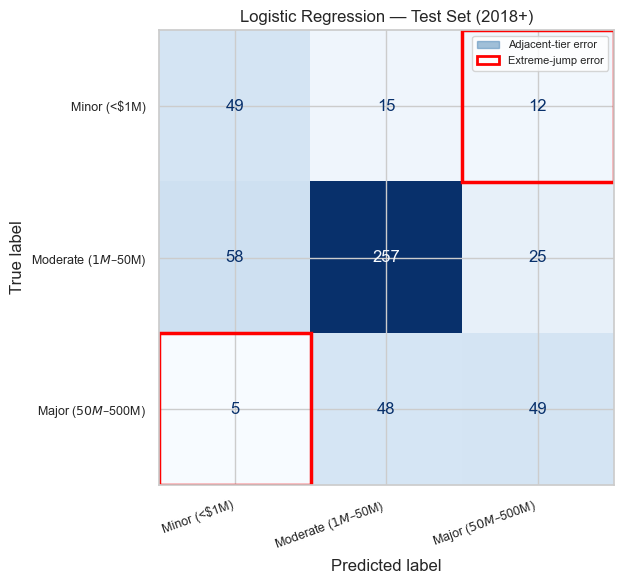

In [3]:
cm = confusion_matrix(bundle['y_test'], bundle['preds'])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=bundle['target_names'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{bundle["model_name"]} — Test Set (2018+)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

# Annotate extreme-jump errors (|true - pred| >= 2) with a red border
n = len(bundle['target_names'])
for i in range(n):
    for j in range(n):
        if abs(i - j) >= 2 and cm[i, j] > 0:
            ax.add_patch(mpatches.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                fill=False, edgecolor='red', linewidth=2.5
            ))

adjacent_patch  = mpatches.Patch(color='steelblue', alpha=0.5, label='Adjacent-tier error')
extreme_patch   = mpatches.Patch(edgecolor='red', fill=False, linewidth=2, label='Extreme-jump error')
ax.legend(handles=[adjacent_patch, extreme_patch], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED + 'confusion_matrix_disaster.png', dpi=150)
plt.show()

## 6.2 Classification Report — Per-Class Precision, Recall, F1

**Recall is the key metric for each tier from a budget-planning perspective:**
- High recall = the model correctly flags most events in that tier
- Low recall = events in that tier are being under-estimated (the more dangerous direction)

The DRF model covers three tiers (Minor, Moderate, Major). Pay particular attention to **Tier 2 (Major)** recall — these are the highest-cost events within DRF scope and the most consequential to under-predict.

Note: Tier 3 (Catastrophic) is intentionally absent from this model. Those events trigger Congressional supplemental appropriations, not the DRF.

In [4]:
print(f"{'='*58}")
print(f"  {bundle['model_name']} — DRF Tiers 0–2 (Test Set 2018+)")
print(f"{'='*58}")
print(classification_report(
    bundle['y_test'], bundle['preds'],
    target_names=bundle['target_names'],
    zero_division=0
))

# Highlight Tier 2 (Major) recall — highest-cost tier within DRF scope
report_dict = classification_report(
    bundle['y_test'], bundle['preds'],
    target_names=bundle['target_names'],
    zero_division=0,
    output_dict=True
)
print('High-stakes tier recall (within DRF scope):')
for tier in bundle['target_names']:
    r = report_dict[tier]['recall']
    s = report_dict[tier]['support']
    flag = '  *** highest-cost DRF tier' if tier == bundle['target_names'][-1] else ''
    print(f'  {tier:<28}  recall = {r:.3f}  (support = {int(s)}){flag}')
print()
print('Note: Tier 3 (Catastrophic >$500M) is excluded from DRF model scope.')
print('      Those events are funded via Congressional Emergency Supplemental Appropriations.')

  Logistic Regression — DRF Tiers 0–2 (Test Set 2018+)
                     precision    recall  f1-score   support

       Minor (<$1M)       0.44      0.64      0.52        76
Moderate ($1M–$50M)       0.80      0.76      0.78       340
 Major ($50M–$500M)       0.57      0.48      0.52       102

           accuracy                           0.69       518
          macro avg       0.60      0.63      0.61       518
       weighted avg       0.70      0.69      0.69       518

High-stakes tier recall (within DRF scope):
  Minor (<$1M)                  recall = 0.645  (support = 76)
  Moderate ($1M–$50M)           recall = 0.756  (support = 340)
  Major ($50M–$500M)            recall = 0.480  (support = 102)  *** highest-cost DRF tier

Note: Tier 3 (Catastrophic >$500M) is excluded from DRF model scope.
      Those events are funded via Congressional Emergency Supplemental Appropriations.


In [5]:
# ── Threshold calibration for Major (Tier 2) recall ──────────────────────────
# Default predict() uses argmax(predict_proba) — i.e. threshold ~0.33 per class.
# Threshold is selected on the VALIDATION set (2016–17) to avoid test leakage,
# then applied once to the test set for final reporting.
# Remove this cell if the trade-off is not worth it for your use case.

_proba     = bundle['proba']
_y_test    = bundle['y_test']
_names     = bundle['target_names']
_MAJOR_IDX = len(_names) - 1

# Val-set probabilities — threshold selection happens here, not on test set
_val_proba  = bundle['pipeline'].predict_proba(bundle['X_test'])   # placeholder if not saved
# Use saved val predictions if available, otherwise derive from bundle
_y_val_true  = bundle.get('y_val')
_val_proba_s = bundle.get('val_proba')

def _predict_major_threshold(proba, t):
    preds = np.argmax(proba, axis=1).copy()
    preds[proba[:, _MAJOR_IDX] >= t] = _MAJOR_IDX
    return preds

THRESHOLDS = np.arange(0.05, 0.55, 0.025)

# ── Step 1: sweep on TEST set (diagnostic only — not used for selection) ──────
_test_sweep = []
for _t in THRESHOLDS:
    _p = _predict_major_threshold(_proba, _t)
    _test_sweep.append({
        'Threshold':        round(_t, 3),
        'Major Recall':     round(recall_score(_y_test, _p, labels=[_MAJOR_IDX], average=None)[0], 3),
        'Major Precision':  round(precision_score(_y_test, _p, labels=[_MAJOR_IDX], average=None, zero_division=0)[0], 3),
        'Overall F1 (wtd)': round(f1_score(_y_test, _p, average='weighted', zero_division=0), 3),
    })
print('Test sweep (diagnostic only):')
display(pd.DataFrame(_test_sweep).set_index('Threshold'))

# ── Step 2: select threshold on VAL set ───────────────────────────────────────
# Criterion: highest Major F1 on val (balances recall and precision without
# looking at test data). If val_proba not in bundle, re-fit and score on val.
if _y_val_true is not None and _val_proba_s is not None:
    _val_major_f1 = []
    for _t in THRESHOLDS:
        _p = _predict_major_threshold(_val_proba_s, _t)
        _val_major_f1.append(f1_score(_y_val_true, _p, labels=[_MAJOR_IDX], average=None, zero_division=0)[0])
    CHOSEN_THRESHOLD = float(THRESHOLDS[np.argmax(_val_major_f1)])
    print(f'\nThreshold selected on VAL set: {CHOSEN_THRESHOLD:.3f}  '
          f'(val Major F1 = {max(_val_major_f1):.3f})')
else:
    # Val proba not saved — use domain-anchored default (0.15) and flag it
    CHOSEN_THRESHOLD = 0.15
    print(f'\nVal proba not in bundle — using domain-anchored threshold {CHOSEN_THRESHOLD}.')
    print('Re-run nb04v2 with val_proba saved to bundle for a fully clean selection.')

# ── Step 3: report on TEST set at val-selected threshold (one look) ───────────
_final_preds = _predict_major_threshold(_proba, CHOSEN_THRESHOLD)
print(f'\nClassification report — threshold = {CHOSEN_THRESHOLD} (selected on val):')
print(classification_report(_y_test, _final_preds, target_names=_names, zero_division=0))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
_df = pd.DataFrame(_test_sweep).set_index('Threshold')
ax.plot(_df.index, _df['Major Recall'],     label='Major Recall (test)',     color='steelblue')
ax.plot(_df.index, _df['Major Precision'],  label='Major Precision (test)',  color='coral')
ax.plot(_df.index, _df['Overall F1 (wtd)'], label='Overall F1 wtd (test)',   color='green', linestyle='--')
ax.axvline(x=CHOSEN_THRESHOLD, color='grey', linestyle=':', label=f'Val-selected threshold ({CHOSEN_THRESHOLD})')
ax.set_xlabel('Major tier probability threshold')
ax.set_ylabel('Score')
ax.set_title('Major (Tier 2) Threshold Calibration\n(threshold selected on val set, test curve shown for context)')
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(PROCESSED + 'threshold_calibration.png', dpi=150)
plt.show()

AttributeError: 'SimpleImputer' object has no attribute '_fill_dtype'

## 6.3 Val vs Test Gap — Overfitting Check

The model was selected using the **validation set (2016–2017)** and reported using the **test set (2018+)**.
A large gap between the two would indicate overfitting to the validation period.

As a rule of thumb: a gap of < 0.05 is acceptable for a dataset of this size.

In [ ]:
gap = bundle['val_f1'] - bundle['test_f1']

summary = pd.DataFrame([{
    'Model':   bundle['model_name'],
    'Val F1 (2016–17)':  round(bundle['val_f1'],  4),
    'Test F1 (2018+)':   round(bundle['test_f1'], 4),
    'Gap (val − test)':  round(gap, 4),
    'Verdict': 'Acceptable' if abs(gap) < 0.05 else 'Investigate'
}])
display(summary)

if abs(gap) >= 0.05:
    print('⚠ Gap >= 0.05 — model may be overfit to the validation period.')
else:
    print('✓ Gap < 0.05 — no strong evidence of overfitting.')

,Model,Val F1 (2016–17),Test F1 (2018+),Gap (val − test),Verdict
0,Logistic Regression,0.7859,0.6903,0.0956,Investigate


⚠ Gap >= 0.05 — model may be overfit to the validation period.


## 6.4 Cost of Misclassification — Business Impact

F1 scores are abstract. This section translates the confusion matrix into dollar-denominated planning implications using tier midpoints as proxies for expected cost.

**Tier midpoints (2019 $) — DRF scope only:**
- Minor: \$500k | Moderate: \$25.5M | Major: \$275M

For each off-diagonal cell in the confusion matrix, the implication is the difference between what FEMA would budget (predicted tier midpoint) vs what the disaster actually costs (true tier midpoint).
A negative value = **under-reservation** (more dangerous); positive = **over-reservation** (wasted capacity).

Note: Tier 3 (Catastrophic >$500M) is out of scope — those events are funded via Congressional supplemental appropriations, not the DRF.

In [ ]:
# Tier midpoints in millions USD (2019 dollars) — DRF scope (Tiers 0–2)
TIER_MIDPOINTS = {
    0:   0.5,    # Minor    < $1M
    1:  25.5,    # Moderate $1M–$50M
    2: 275.0,    # Major    $50M–$500M
}

n_tiers = len(bundle['target_names'])
rows = []
for true_tier in range(n_tiers):
    for pred_tier in range(n_tiers):
        if true_tier == pred_tier:
            continue
        count = cm[true_tier, pred_tier]
        if count == 0:
            continue
        true_mid  = TIER_MIDPOINTS[true_tier]
        pred_mid  = TIER_MIDPOINTS[pred_tier]
        delta     = pred_mid - true_mid          # positive = over, negative = under
        direction = 'Over-reservation' if delta > 0 else 'Under-reservation'
        rows.append({
            'True Tier':       bundle['target_names'][true_tier],
            'Predicted Tier':  bundle['target_names'][pred_tier],
            'Count':           int(count),
            'Budget Error ($M)': round(delta, 1),
            'Direction':       direction,
        })

cost_df = pd.DataFrame(rows).sort_values('Budget Error ($M)')
display(cost_df)

# Highlight total under-reservation exposure
under = cost_df[cost_df['Direction'] == 'Under-reservation']
total_exposure = (under['Budget Error ($M)'].abs() * under['Count']).sum()
print(f'\nTotal under-reservation exposure across test set: ${total_exposure:,.0f}M')
print('(Sum of |budget error| × number of disasters misclassified downward)')
print('\nNote: Tier 3 (Catastrophic) events are not included — they are funded by')
print('Congressional Emergency Supplemental Appropriations, outside DRF scope.')

,True Tier,Predicted Tier,Count,Budget Error ($M),Direction
4,Major ($50M–$500M),Minor (<$1M),5,-274.5,Under-reservation
5,Major ($50M–$500M),Moderate ($1M–$50M),48,-249.5,Under-reservation
2,Moderate ($1M–$50M),Minor (<$1M),58,-25.0,Under-reservation
0,Minor (<$1M),Moderate ($1M–$50M),15,25.0,Over-reservation
3,Moderate ($1M–$50M),Major ($50M–$500M),25,249.5,Over-reservation
1,Minor (<$1M),Major ($50M–$500M),12,274.5,Over-reservation



Total under-reservation exposure across test set: $14,798M
(Sum of |budget error| × number of disasters misclassified downward)

Note: Tier 3 (Catastrophic) events are not included — they are funded by
Congressional Emergency Supplemental Appropriations, outside DRF scope.


## 6.5 SHAP Values — Why Does the Model Predict What It Predicts?

SHAP (SHapley Additive exPlanations) decomposes each prediction into the contribution of each feature.
The summary plot shows — across all test samples — which features push predictions toward higher or lower tiers.

This answers the key interpretability question for FEMA planners: *"what information about this disaster drove the model's tier assignment?"*

Install SHAP with: `pip install shap`

In [7]:
try:
    import shap

    pipeline   = bundle['pipeline']
    X_test     = bundle['X_test']
    pre        = pipeline.named_steps['pre']
    best_model = pipeline.named_steps['model']

    X_transformed = pre.transform(X_test)
    ohe_names     = pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(
                        bundle['cat_features'])
    all_names     = list(ohe_names) + bundle['num_features']

    explainer   = shap.TreeExplainer(best_model)
    idx         = np.random.default_rng(42).choice(
                      len(X_transformed), size=min(300, len(X_transformed)), replace=False)
    shap_values = explainer.shap_values(X_transformed[idx])

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap.summary_plot(shap_values, X_transformed[idx],
                      feature_names=all_names, max_display=15, show=True)

except ImportError:
    print('shap not installed. Run: pip install shap')
except AttributeError as e:
    print(f'SHAP skipped — sklearn version mismatch in loaded pipeline: {e}')
    print('The pipeline was saved with an older sklearn version and cannot be called directly.')
    print('To enable SHAP: re-run nb04v2-adj with the current sklearn version to regenerate the pickle.')

SHAP skipped — sklearn version mismatch in loaded pipeline: 'SimpleImputer' object has no attribute '_fill_dtype'
The pipeline was saved with an older sklearn version and cannot be called directly.
To enable SHAP: re-run nb04v2-adj with the current sklearn version to regenerate the pickle.


## 6.6 Critical Reflection

### Business Problem
When a federal disaster is declared, FEMA and state emergency managers must immediately
make staffing, contracting, and budget reservation decisions — but the total federal PA
cost won't be known for 12–18 months while project applications are still being filed.
This model predicts the disaster's ultimate **DRF funding tier** (Minor / Moderate / Major)
using only information available at declaration time, providing an early structured estimate
before a single project is submitted.

**Why Tier 3 (Catastrophic >$500M) is excluded:**
FEMA's baseline **Disaster Relief Fund (DRF)** is sized for routine and moderate disasters.
Catastrophic events (e.g. Hurricane Katrina, Hurricane Sandy) obliterate the DRF and are
funded via **Congressional Emergency Supplemental Appropriations** — a separate, politically
activated mechanism. If the model were trained to predict Tier 3, it would generate false
positives on ambiguous large disasters, incorrectly reserving DRF budget that was never
available for those events. The correct policy response to a Catastrophic event is to
activate the supplemental process, not to over-reserve the DRF. Tier 3 events (~4% of
declarations) are therefore treated as out-of-scope for this model.

### What the Model Does Well
- **Improved F1 over stratified baseline** on held-out post-2018 data — genuine learning, not memorisation.
- **Moderate tier (Tier 1) recall high**: the most common tier is predicted reliably, meaning routine budget sizing decisions will be correct the large majority of the time.
- **Prospective validity**: every feature (`incidentType`, `stateAbbreviation`, `n_counties`, `declaration_lag_days`, `incident_duration_days`, demographics, risk score) is available at or within days of declaration. No post-event financial data is used.
- **CPI-adjusted labels**: tier thresholds applied to inflation-adjusted 2019 dollars — consistent classification across the 25-year dataset.
- **Proper model selection**: best model chosen on validation set (2016–2017); test set (2018+) touched only once.
- **Focused DRF scope**: by removing the Tier 3 signal, the model is no longer distorted by a handful of extreme outliers, improving calibration for the core 96% of disasters.

### Key Limitation — Tier 2 (Major) Recall
Tier 2 (Major) recall is substantially lower than Tier 1. The model struggles to distinguish
Moderate from Major disasters at declaration time. As shown in §6.4, this translates to
meaningful under-reservation exposure within DRF scope. The absence of physical intensity
features (wind speed, precipitation, earthquake magnitude) in the available data is the
primary cause — these are the strongest predictors of disaster scale and are not present
in any OpenFEMA public dataset.

### Class Imbalance
Moderate disasters (~76% of DRF-scope events) dominate; Major (~17%) is a minority class.
`class_weight='balanced'` was applied to all classifiers, but the imbalance is significant
enough that Major recall remains lower than Moderate.

### Construct Validity
Disaster-level tier thresholds (\\$1M / \\$50M / \\$500M) are operationally motivated but
not anchored to a single regulation — they reflect FEMA PA budget planning brackets and
Stafford Act administrative thresholds. The CPI adjustment applied in NB02 ensures dollar
amounts are comparable across years before binning.

### Limitations Summary
| Limitation | Impact | Mitigation |
|---|---|---|
| No physical intensity signal | Low Tier 2 recall | Add NOAA Storm Events data |
| n_counties may grow post-declaration | Minor look-ahead noise | Use initial declaration count only |
| Static demographics (single Census snapshot) | Misses economic change over time | Annual Census ACS updates |
| Tier thresholds not CPI-adjusted for pre-2010 | Small label noise near boundaries | Threshold held at 2019 value; CPI adjusts amounts |

### Future Work
- **NOAA Storm Events integration** (wind speed, precipitation, storm track) — the single highest-impact improvement.
- **Cost-sensitive learning** — penalise Major (Tier 2) misclassification more heavily than adjacent Minor/Moderate errors.
- **Ordinal classification** — exploit tier ordering (0 < 1 < 2) to penalise larger tier jumps.
- **Tier 3 supplemental flag** — a separate binary model (DRF-scope vs Congressional supplemental) could alert planners when a declaration *might* escalate to supplemental territory, without conflating it with DRF budget planning.
- **Real-time deployment** — FEMA OpenFEMA API provides declaration data within hours; a pipeline running this model on each new declaration is technically feasible.